## 🔄 TopFarm

**Concepts:** [Choosing a router](../routers.md#choosing-a-router) · [Warm-starting](../routers.md#warm-starting)

This notebook presents a minimal wind-farm design optimization that couples **OptiWindNet** for electrical-network routing with **[TopFarm](https://gitlab.windenergy.dtu.dk/TOPFARM)** for turbine-layout optimization. The standalone **`costmodels`** package provides offshore CAPEX, OPEX, and project-finance calculations.

Three cost components are coupled:

- **Energy (AEP)**: PyWake evaluates farm energy for a set of wind directions and turbine coordinates.
- **Electrical network (cabling)**: based on turbine/substation coordinates and the cable catalog, `WFNComponent` (a TopFarm wrapper around OptiWindNet's [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork)) returns cabling cost (and gradients).
- **Economics (NPV)**: a `costmodels.project.Project` with a `Technology` backed by `DTUOffshoreCostModel` returns project NPV given AEP and cabling cost. NPV is the optimization **objective** (`maximize=True`); IRR, LCOE, CAPEX and OPEX are tracked as auxiliary outputs.

OptiWindNet's inner router uses cable length as its objective; `WFNComponent` passes the cost of that routed network into TopFarm's outer NPV objective. The inner network is not guaranteed to be the cheapest feasible network; see [Objective and reported cost](../problem.md#objective-and-reported-cost).

The optimizer controls the following design variables:

- `x`, `y`: turbine coordinates (one entry per turbine)
- `xs`, `ys`: **substation coordinates** — letting TopFarm co-locate the substation alongside the turbines can reduce total cabling cost. The boundary constraint applies to turbines only; the substation is unconstrained, so its trajectory may exit the site polygon. The final substation position is shown in a dedicated trajectory plot at the end.

**TopFarm integration**

1. Instantiate `aep_comp`, `network_cost_comp`, and `npv_comp`.
2. Combine them in a `TopFarmGroup([aep_comp, network_cost_comp, npv_comp])`. Variable promotion connects their inputs and outputs:

   - `aep_comp` produces **AEP** used by the economic component.
   - `network_cost_comp` produces **cabling_cost** also used by the economic component.
   - The economic component outputs **NPV**, which TopFarm treats as the **objective**.

3. Create a `TopFarmProblem` with the turbine **and substation** coordinates as design variables, the `TopFarmGroup` cost component, the layout constraints, and a driver.
4. Call the `TopFarmProblem.optimize()` method.

Data flow: `(turbine and substation positions) → AEP and cabling_cost → NPV (objective)`. Constraints keep the turbine layout feasible; the selected OptiWindNet router controls the network quality/runtime trade-off.

[Choosing a router](../routers.md#choosing-a-router) discusses router selection for the inner loop. Because the outer optimization re-solves the network on every iteration, the constructive heuristic is often the practical choice. See [📐 Gradients](hi50_gradient.ipynb) for gradients and [🚧 Borders & Obstacles](hi13_border_obstacles.ipynb) for buffering.

> **Note on boundaries and buffering**
>
> TopFarm’s gradient-based drivers occasionally move turbines a little outside the user-defined site polygon while searching the design space. OptiWindNet can accommodate these small excursions with `wfn.add_buffer(buffer_dist=dist)`, which expands the outer border and shrinks any obstacle polygons by `dist` before it optimizes the electrical network.
>
> This example omits the border when constructing [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) because the rectangular site has no concavities or internal obstacles and the TopFarm driver's maximum overshoot is not known in advance. For a project with concavities or exclusion zones:
>
> 1. **Estimate the maximum overshoot** the chosen TopFarm driver may produce (e.g. by running a few test iterations or inspecting previous layouts).
> 2. Call `wfn.add_buffer(buffer_dist=max_overshoot)` _before_ optimization, or pass the buffered border and obstacles directly when creating the [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork).
>
> This confines the geometry relaxation to the estimated excursion distance.

Import required packages

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

In [2]:
from costmodels.finance import Depreciation, Product, Technology
from costmodels.models import DTUOffshoreCostModel
from costmodels.project import Project
from py_wake import Nygaard_2022
from py_wake.examples.data.dtu10mw import DTU10MW
from py_wake.examples.hornsrev1_example import Hornsrev1Site
from topfarm import TopFarmGroup, TopFarmProblem
from topfarm.constraint_components.boundary import XYBoundaryConstraint
from topfarm.constraint_components.constraint_aggregation import (
    DistanceConstraintAggregation,
)
from topfarm.cost_models.cost_model_wrappers import CostModelComponent
from topfarm.cost_models.electrical.optiwindnet_wrapper import WFNComponent
from topfarm.cost_models.py_wake_wrapper import PyWakeAEPCostModelComponent
from topfarm.easy_drivers import EasySGDDriver
from topfarm.plotting import XYPlotComp

from optiwindnet.api import MILPRouter
from optiwindnet.augmentation import poisson_disc_filler

In [3]:
%config InlineBackend.figure_formats = ['svg']
plt.rcParams['svg.fonttype'] = 'none'

# matplotlib >=3.9 removed rcsetup.interactive_bk (moved to backend_registry);
# restore it so topfarm.plotting works with newer matplotlib
import matplotlib

if not hasattr(matplotlib.rcsetup, 'interactive_bk'):
    from matplotlib.backends.registry import BackendFilter, backend_registry

    matplotlib.rcsetup.interactive_bk = backend_registry.list_builtin(
        BackendFilter.INTERACTIVE
    )
    matplotlib.rcsetup.non_interactive_bk = backend_registry.list_builtin(
        BackendFilter.NON_INTERACTIVE
    )
    matplotlib.rcsetup.all_backends = backend_registry.list_builtin()

### Wind farm design parameters

Define turbine type and count:

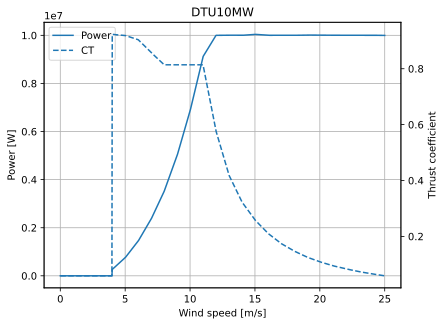

In [4]:
wind_turbines = DTU10MW()
n_wt = 20
wind_turbines.plot_power_ct();

Define the wind resource:

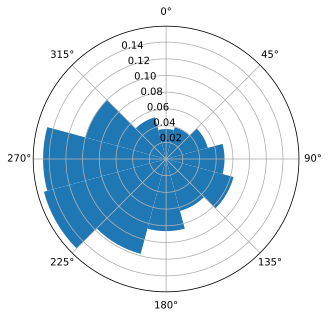

In [5]:
site = Hornsrev1Site()
site.plot_wd_distribution();

Define the area:

In [6]:
d_west_east = 4000  # [m] width
d_south_north = 2000  # [m] height
min_wt_spacing = 3.5 * wind_turbines.diameter()  # [m] inter-turbine minimum distance
boundary = np.array(
    [
        (0, 0),
        (d_west_east, 0),
        (d_west_east, d_south_north),
        (0, d_south_north),
    ]
)

Define the substation position (will also be a design variable in the optimization):

In [7]:
x_ss_init, y_ss_init = (d_west_east / 5, d_south_north / 2)

### Initial wind farm layout (turbine positions)

In [8]:
# Generate initial random turbine layout
x_init, y_init = poisson_disc_filler(
    n_wt,
    min_dist=min_wt_spacing,
    BorderC=boundary,
    seed=42,
).T

### Build components

#### AEP component

In [9]:
# number of wind directions to consider
n_wd = 12

wfm = Nygaard_2022(site=site, windTurbines=wind_turbines)

aep_comp = PyWakeAEPCostModelComponent(
    windFarmModel=wfm,
    n_wt=n_wt,
    wd=np.linspace(0.0, 360.0, n_wd, endpoint=False),
    objective=False,
)

#### Electrical network component

##### Choose the router

Select an OptiWindNet router:

**EWRouter**

```python
from optiwindnet.api import EWRouter
router = EWRouter()
```

**HGSRouter**

```python
from optiwindnet.api import HGSRouter
router = HGSRouter(time_limit=0.1) # seconds
```

**MILPRouter**

```python
from optiwindnet.api import MILPRouter
router = MILPRouter(
 solver_name='gurobi', # or 'highs', 'cplex'
 time_limit=1, # seconds
 mip_gap=0.005, # relative optimality gap (0.5%)
 verbose=True
)
```

> `WFNComponent` forwards the selected `router` to OptiWindNet's [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork). Before using [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter), install a supported solver and, where required, its license.

This example uses [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter). Replace it with either router shown above to change the inner-loop optimization method.

In [10]:
router = MILPRouter(solver_name='ortools.cp_sat', time_limit=0.1, mip_gap=0.005)

Assemble initial turbine/substation positions in OptiWindNet format.

In [11]:
turbines_pos = np.column_stack((x_init, y_init))
substations_pos = np.column_stack(([x_ss_init], [y_ss_init]))

Define cables. Each row is `[<max number of turbines this cable can carry>, <cable price in €/m>]`.

In [12]:
cables = np.array([(2, 2000), (5, 2200)])

Build the cabling cost component using TopFarm's `WFNComponent` (a thin wrapper around OptiWindNet's [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) exposing cost and gradient hooks). The component takes turbine and substation coordinates as inputs and outputs `cabling_cost` (plus the network length and topology-aware [terse_links](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork.terse_links)).

In [13]:
network_cost_comp = WFNComponent(
    turbines_pos=turbines_pos,
    substations_pos=substations_pos,
    cables=cables,
    router=router,
)

The component builds one [WindFarmNetwork](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.WindFarmNetwork) and re-optimizes that same object at every design evaluation, so only the first solve starts from nothing. From the second evaluation on, [MILPRouter](../autoapi/optiwindnet/api/index.rst#optiwindnet.api.MILPRouter) is handed the previous layout’s network as its warm start, and rebuilds one only if the moved turbines left a network the new model cannot take. The turbines move little between evaluations, so the previous optimum stays close to the new one — which is what makes a `time_limit` of 0.1 s workable inside this loop, where the standalone sample above uses 1 s.

The first evaluation has nothing to reuse, so the router builds a warm start itself, within `warmup_time` (0.2 s by default, and never more than `time_limit`). Passing `warmup=False` turns warm-starting off and solves every evaluation cold. Both controls are demonstrated in [🔧 Options](hi31_options.ipynb).

#### Economic component (NPV objective)

The `costmodels` package assembles a single-technology offshore wind project. `DTUOffshoreCostModel` provides the technology-level CAPEX/OPEX cost model; `Technology` wraps it with finance parameters (lifetime, WACC, OPEX, product); `Project` aggregates technologies into a project that computes NPV, with IRR, LCOE, CAPEX, and OPEX as auxiliary outputs.

The `economic_func` function takes `AEP` in GWh and `cabling_cost` in euros and returns the project NPV together with the auxiliary outputs. Its analytical gradient, `economic_func_grad`, returns the NPV derivatives with respect to AEP and cabling cost. Passing cabling cost as `shared_capex` adds it to project CAPEX. This example holds water depth fixed across the site.

In [14]:
LIFETIME = 25  # [years]
EL_PRICE = 60  # [€/MWh] flat PPA price (matches the original notebook's 0.06 €/kWh)
WATER_DEPTH = 33.0  # [m] uniform site water depth
DISTANCE_FROM_SHORE = (
    30  # [km] (informational — not used by DTUOffshoreCostModel directly)
)

RP_MW = float(wind_turbines.power(20.0)) * 1e-6  # rated power [MW]

# Reference AEP (used only to initialize the model with a plausible capacity factor)
_simres_ref = wfm(x_init, y_init)
_aep_ref_gwh = float(_simres_ref.aep().values.sum())
CF_ref = _aep_ref_gwh * 1e3 / (RP_MW * 24 * 365 * n_wt)

cost_model = DTUOffshoreCostModel(
    rated_power=RP_MW,
    rotor_speed=12.0,
    rotor_diameter=wind_turbines.diameter(),
    hub_height=wind_turbines.hub_height(),
    lifetime=LIFETIME,
    capacity_factor=CF_ref,
    nwt=n_wt,
    profit=0,
)

wind_plant = Technology(
    name='wind',
    lifetime=LIFETIME,
    product=Product.SPOT_ELECTRICITY,
    opex=12600 * n_wt * RP_MW + 1.35 * _aep_ref_gwh * 1000,  # [€/yr]
    wacc=0.06,
    cost_model=cost_model,
)

project = Project(
    technologies=[wind_plant],
    product_prices={Product.SPOT_ELECTRICITY: EL_PRICE},
    depreciation=Depreciation(rate=(0, 1), year=(0, LIFETIME)),
)

water_depth_array = np.full((n_wt,), WATER_DEPTH)

In [15]:
def economic_func(AEP, cabling_cost, **kwargs):
    aep_mwh = AEP * 1e3  # GWh → MWh
    npv, aux = project.npv(
        productions={wind_plant.name: aep_mwh},
        cost_model_args={
            wind_plant.name: {'water_depth': water_depth_array, 'aep': aep_mwh},
        },
        finance_args={'shared_capex': cabling_cost},
        return_aux=True,
    )
    return npv, {
        'IRR': aux['IRR'],
        'LCOE': aux['LCOE'][0],
        'CAPEX': aux['CAPEX'],
        'OPEX': float(np.mean(aux['OPEX'])),
    }


def economic_func_grad(AEP, cabling_cost, **kwargs):
    aep_mwh = AEP * 1e3
    grad = project.npv_grad(
        productions={wind_plant.name: aep_mwh},
        cost_model_args={
            wind_plant.name: {'water_depth': water_depth_array, 'aep': aep_mwh},
        },
        finance_args={'shared_capex': cabling_cost},
    )
    return (
        grad[0][wind_plant.name] * 1e3,  # dNPV/dAEP (chain rule for GWh→MWh)
        grad[2]['shared_capex'],  # dNPV/dCablingCost
    )

In [16]:
npv_comp = CostModelComponent(
    input_keys=[('AEP', 0.0), ('cabling_cost', 0.0)],
    n_wt=n_wt,
    cost_function=economic_func,
    cost_gradient_function=economic_func_grad,
    output_keys=[('NPV', 0.0)],
    additional_output=[
        ('IRR', 0.0),
        ('LCOE', 0.0),
        ('CAPEX', 0.0),
        ('OPEX', 0.0),
    ],
    objective=True,
    maximize=True,
)

### Build TopFarm problem

Combine the three cost components in a `TopFarmGroup`.

In [17]:
cost_comp = TopFarmGroup(
    [
        aep_comp,
        network_cost_comp,
        npv_comp,
    ]
)

Create the `TopFarmProblem`. Design variables are the turbine coordinates `x`, `y` **and** the substation coordinates `xs`, `ys` — letting the optimizer co-locate the substation can reduce total cabling cost.

In [18]:
tf_problem = TopFarmProblem(
    design_vars={
        'x': x_init,
        'y': y_init,
        'xs': x_ss_init,
        'ys': y_ss_init,
    },
    cost_comp=cost_comp,
    constraints=DistanceConstraintAggregation(
        XYBoundaryConstraint(boundary, 'polygon'),
        n_wt,
        min_wt_spacing,
        wind_turbines,
    ),
    driver=EasySGDDriver(maxiter=500),
    plot_comp=XYPlotComp(),
)

### Run optimization

The example uses `maxiter=500` for a substantive optimization. Reduce it to shorten the end-to-end runtime.

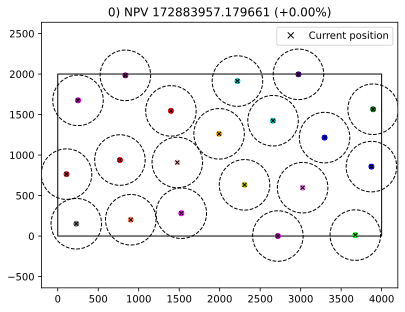

Optimized in	123.167s


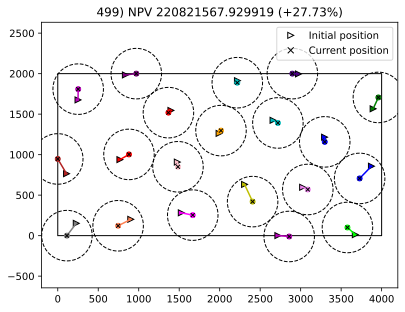

In [19]:
cost, state, recorder = tf_problem.optimize(disp=True)

### Plotting

Track AEP, cabling cost, NPV, IRR and constraint violation over time.

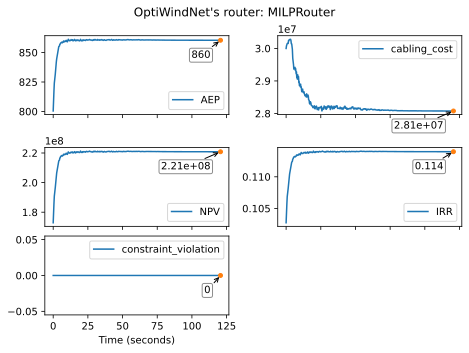

In [20]:
records_to_plot = ['AEP', 'cabling_cost', 'NPV', 'IRR', 'constraint_violation']
time = recorder['timestamp'] - recorder['timestamp'][0]
n_rows = math.ceil(len(records_to_plot) / 2)
fig, axs = plt.subplots(n_rows, 2, sharex=True, layout='constrained')

for ax, key in zip(axs.ravel(), records_to_plot):
    (line,) = ax.plot(time, recorder[key], label=key)
    ax.legend()
    x_last, y_last = line.get_xdata()[-1], line.get_ydata()[-1]
    ax.plot(x_last, y_last, 'o', ms=4)
    ax.annotate(
        f'{y_last:.3g}',
        xy=(x_last, y_last),
        xytext=(-10, -10),
        textcoords='offset points',
        ha='right',
        va='top',
        arrowprops={'arrowstyle': '->', 'lw': 1},
        bbox={'boxstyle': 'round,pad=0.2', 'fc': 'white', 'ec': '0.5', 'alpha': 0.9},
    )

# hide any unused axes (when records_to_plot is odd)
for ax in axs.ravel()[len(records_to_plot) :]:
    ax.set_visible(False)

for ax in axs[-1, :]:
    ax.set_xlabel('Time (seconds)')

fig.suptitle(f"OptiWindNet's router: {type(router).__name__}");

#### Substation trajectory

Because `xs`, `ys` are design variables (and unconstrained by the site polygon), the substation drifts during optimization. The plot below overlays the site boundary, the **initial** substation position (open marker), the **final** position (filled marker), and the **path** the optimizer took, plus the final turbine layout for context.

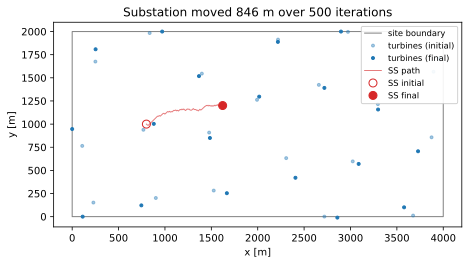

In [21]:
xs_path = np.asarray(recorder['xs']).reshape(-1)
ys_path = np.asarray(recorder['ys']).reshape(-1)
x_final = np.asarray(recorder['x'])[-1].reshape(-1)
y_final = np.asarray(recorder['y'])[-1].reshape(-1)

fig, ax = plt.subplots(layout='constrained')
ax.set_aspect('equal')

# site boundary
ax.plot(
    np.r_[boundary[:, 0], boundary[0, 0]],
    np.r_[boundary[:, 1], boundary[0, 1]],
    color='0.5',
    lw=1,
    label='site boundary',
)

# turbines (initial vs final)
ax.plot(x_init, y_init, '.', color='C0', alpha=0.4, label='turbines (initial)')
ax.plot(x_final, y_final, '.', color='C0', label='turbines (final)')

# substation trajectory
ax.plot(xs_path, ys_path, '-', color='C3', lw=1, alpha=0.6, label='SS path')
ax.plot(xs_path[0], ys_path[0], 'o', mfc='none', mec='C3', ms=8, label='SS initial')
ax.plot(xs_path[-1], ys_path[-1], 'o', mfc='C3', mec='C3', ms=8, label='SS final')

ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.legend(loc='upper right', fontsize='small', framealpha=0.9)
moved = np.hypot(xs_path[-1] - xs_path[0], ys_path[-1] - ys_path[0])
ax.set_title(f'Substation moved {moved:.0f} m over {len(xs_path)} iterations');

Plot the optimized network for the final wind farm layout.

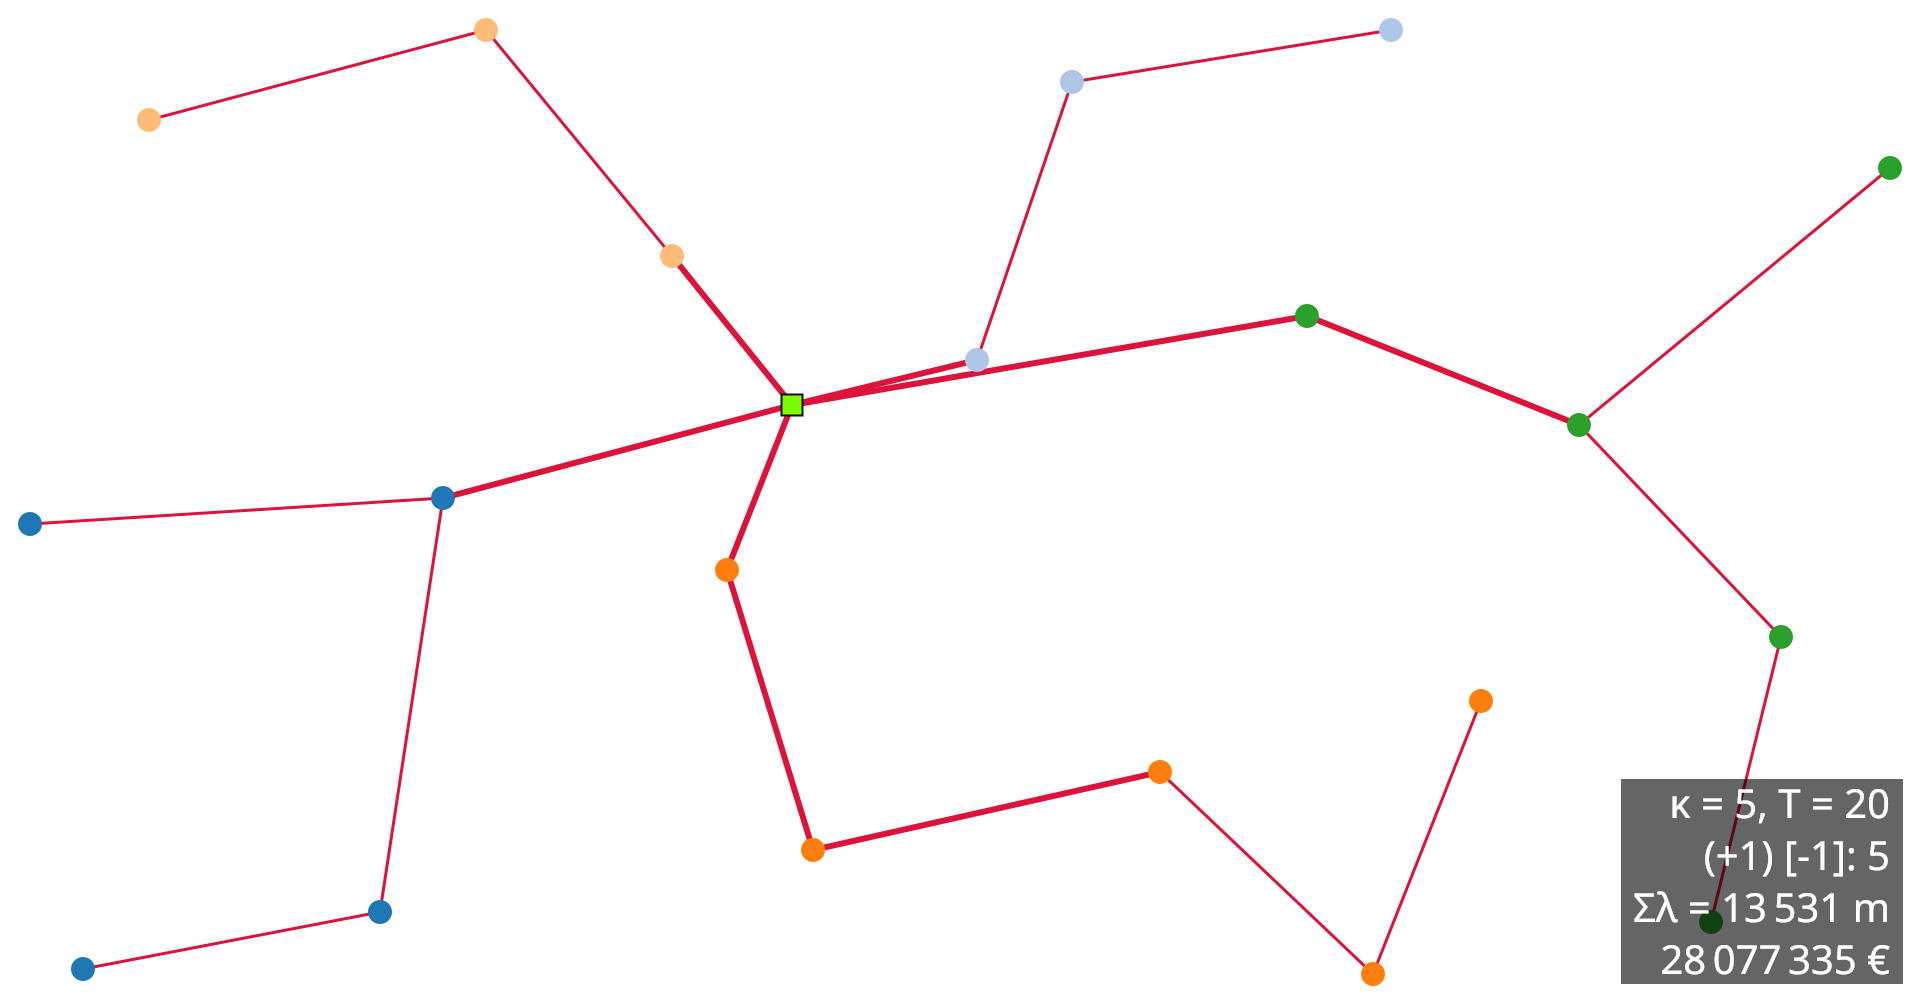

In [22]:
network_cost_comp.wfn.plot()